In [4]:
#importing libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.options.display.max_rows=999

In [5]:
df=pd.read_csv('Student.csv')

In [6]:
df.shape

(50, 7)

In [7]:
print(df)

    roll_no  gender   age  math_score  eng_score  chem_score  placement_score
0         1     1.0  16.0        45.0       44.0         2.0        30.333333
1         2     1.0  15.0        58.0       11.0         NaN              NaN
2         3     1.0  16.0        21.0       14.0        53.0        29.333333
3         4     0.0  16.0        74.0       71.0        32.0        59.000000
4         5     1.0  15.0        76.0       14.0        99.0        63.000000
5         6     1.0  14.0        73.0       16.0        75.0        54.666667
6         7     0.0  16.0        83.0       75.0        58.0        72.000000
7         8     0.0  14.0        12.0       70.0        19.0        33.666667
8         9     0.0  14.0        27.0       84.0        74.0        61.666667
9        10     1.0  15.0         6.0       63.0        20.0        29.666667
10       11     1.0   NaN         4.0       27.0        32.0        21.000000
11       12     1.0  15.0        46.0       59.0        64.0    

In [8]:
#isnull function return true if value is null or NaN
df.isnull()

,roll_no,gender,age,math_score,eng_score,chem_score,placement_score
0,False,False,False,False,False,False,False
1,False,False,False,False,False,True,True
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [9]:
#total null or NaN values in each column
df.isnull().sum()

roll_no            0
gender             2
age                2
math_score         3
eng_score          2
chem_score         3
placement_score    8
dtype: int64

In [10]:
#extra info about the dataset
df.describe()

,roll_no,gender,age,math_score,eng_score,chem_score,placement_score
count,50.00000,48.000000,48.000000,47.000000,48.000000,47.000000,42.000000
mean,25.50000,0.583333,15.583333,40.851064,54.020833,55.021277,49.809524
std,14.57738,0.498224,1.068571,28.745494,27.233810,29.212482,17.303937
min,1.00000,0.000000,14.000000,0.000000,0.000000,2.000000,19.000000
25%,13.25000,0.000000,15.000000,12.500000,33.000000,32.000000,35.250000
50%,25.50000,1.000000,15.500000,45.000000,62.000000,58.000000,50.333333
75%,37.75000,1.000000,16.000000,63.500000,71.000000,79.500000,59.250000
max,50.00000,1.000000,18.000000,92.000000,99.000000,99.000000,83.333333


In [11]:
#filling for NaN values with mean ,max or min 

# mean age 
avg_Age=df['age'].mean()
print('avg age : ',avg_Age)

df['age'].fillna(avg_Age,inplace=True)

# 3 for gender not mention i.e. for Nan
df['gender'].fillna(3,inplace=True)

#mean math
mean_math=df['math_score'].mean()
print("mean math : ",mean_math)

df['math_score'].fillna(mean_math,inplace=True)

#mean  eng
mean_eng=df['eng_score'].mean()
print("mean eng : ",mean_eng)

df['eng_score'].fillna(mean_eng,inplace=True)

# mean chem
mean_chem=df['chem_score'].mean()
print("mean chem : ",mean_chem)

df['chem_score'].fillna(mean_chem,inplace=True)

#0 for NaN placement_score
df['placement_score'].fillna(0,inplace=True)
print(df)

avg age :  15.583333333333334
mean math :  40.851063829787236
mean eng :  54.020833333333336
mean chem :  55.02127659574468
    roll_no  gender        age  math_score  eng_score  chem_score  \
0         1     1.0  16.000000   45.000000  44.000000    2.000000   
1         2     1.0  15.000000   58.000000  11.000000   55.021277   
2         3     1.0  16.000000   21.000000  14.000000   53.000000   
3         4     0.0  16.000000   74.000000  71.000000   32.000000   
4         5     1.0  15.000000   76.000000  14.000000   99.000000   
5         6     1.0  14.000000   73.000000  16.000000   75.000000   
6         7     0.0  16.000000   83.000000  75.000000   58.000000   
7         8     0.0  14.000000   12.000000  70.000000   19.000000   
8         9     0.0  14.000000   27.000000  84.000000   74.000000   
9        10     1.0  15.000000    6.000000  63.000000   20.000000   
10       11     1.0  15.583333    4.000000  27.000000   32.000000   
11       12     1.0  15.000000   46.000000  59.0

<Axes: xlabel='age'>

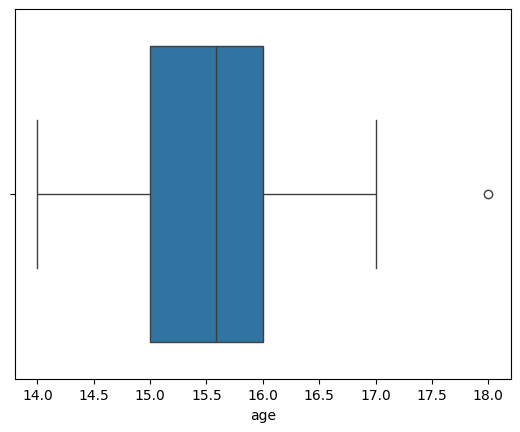

In [12]:
# box plot outlier detection
sns.boxplot(x=df['age'])

Text(0, 0.5, 'age')

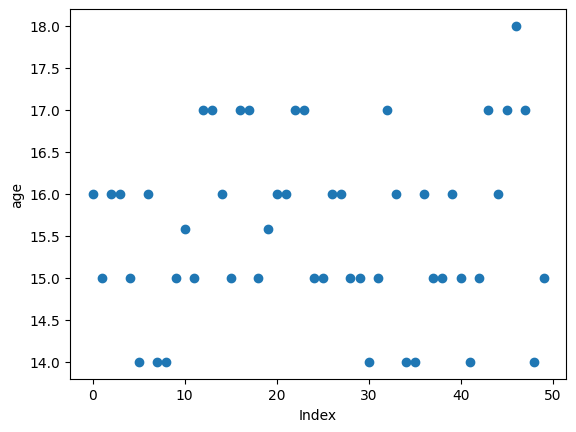

In [13]:
# scatter plotting for outliers
plt.scatter(df.index,df['age'])
plt.xlabel('Index')
plt.ylabel('age')

In [14]:
# detection using IQR technique

q1=df['age'].quantile(0.25)

q3=df['age'].quantile(0.75)

IQR=q3-q1

print('IQR : ',IQR)

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print('lower_bound : ',lower_bound)
print('upper_bound : ',upper_bound)

outliers_iqr=df.query('age <@lower_bound or age>@upper_bound')
print(outliers_iqr)

IQR :  1.0
lower_bound :  13.5
upper_bound :  17.5
    roll_no  gender   age  math_score  eng_score  chem_score  placement_score
46       47     0.0  18.0        10.0       34.0        80.0        41.333333


<Axes: ylabel='age'>

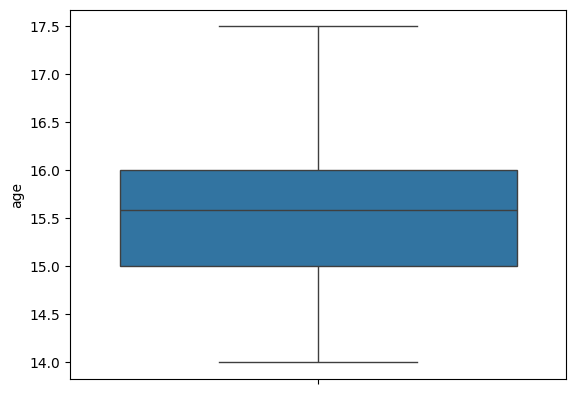

In [15]:
# Apply clipping to the age
df['age'] = df['age'].clip(lower=lower_bound, upper=upper_bound)
sns.boxplot(df['age'])

Text(0, 0.5, 'placement')

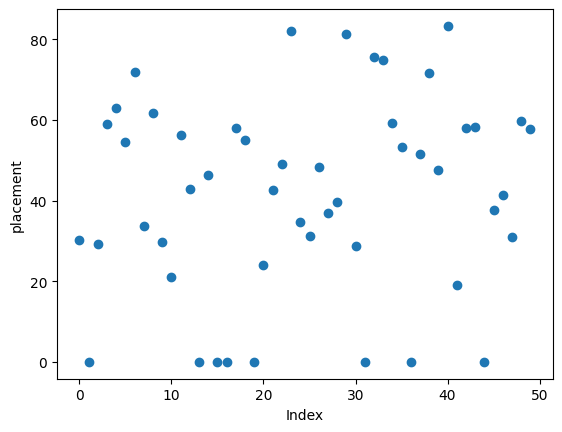

In [16]:
# detecting outliers in placement_score 

# sns.boxplot(df['placement_score'])
plt.scatter(df.index,df['placement_score'])
plt.xlabel('Index')
plt.ylabel('placement')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   roll_no          50 non-null     int64  
 1   gender           50 non-null     float64
 2   age              50 non-null     float64
 3   math_score       50 non-null     float64
 4   eng_score        50 non-null     float64
 5   chem_score       50 non-null     float64
 6   placement_score  50 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 2.9 KB


In [27]:
# Select only numerical  columns for normalization
score_cols = ['math_score', 'eng_score', 'chem_score', 'placement_score']

# Apply Min-Max Scaling: normalise
df[score_cols] = (df[score_cols] - df[score_cols].min()) / (df[score_cols].max() - df[score_cols].min())


In [35]:
# Calculate total score from all subjects
df['total_score'] = df[score_cols].sum(axis=1)

# Add rank column 
df['rank'] = df['total_score'].rank(ascending=False, method='min')

# Sort by rank 
df = df.sort_values('rank')


In [36]:
df.head()
# print(df)

,roll_no,gender,age,math_score,eng_score,chem_score,placement_score,total_score,rank
40,41,1.0,15.0,1.000000,0.646465,0.948454,1.000,3.594918,1.0
23,24,1.0,17.0,0.891304,0.818182,0.835052,0.984,3.528538,2.0
29,30,1.0,15.0,0.565217,1.000000,0.938144,0.976,3.479362,3.0
32,33,1.0,17.0,0.967391,0.707071,0.680412,0.908,3.262874,4.0
33,34,0.0,16.0,0.891304,0.717172,0.721649,0.900,3.230126,5.0
